# Training

In [36]:
import os
import sys
import matplotlib.pyplot as plt
import yaml

sys.path.append('..')

import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
from src.dataset.dataset import VesselDataset
from torch.utils.data import DataLoader, random_split

import torch
import torch.nn as nn
from src.models.loss import DICE_BCE_Loss
from src.utils.resume_training import get_model_from_config, load_checkpoint

from src.models.train import train



In [37]:
# Chargement de la configuration
config_path = '../configs/config_m2unet.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration chargée :")
print(f"| Modèle: {config['model']['name']} ({config['model']['in_channels']} -> {config['model']['out_channels']})")
print(f"| Taille image: {config['data']['image_size']}")
print(f"| Epochs: {config['training']['n_epochs']}")
print(f"| Learning rate: {config['training']['learning_rate']}")
print(f"| Resume training: {config['training']['resume_training']}")

Configuration chargée :
| Modèle: M2Unet (3 -> 1)
| Taille image: 256
| Epochs: 40
| Learning rate: 0.0001
| Resume training: False


## Chargement des données

In [38]:
# Chargement des chemins depuis la config
train_img_path = config['data']['train_img_path']
train_label_path = config['data']['train_label_path']
test_img_path = config['data']['test_img_path']
test_label_path = config['data']['test_label_path']

train_img_files = os.listdir(train_img_path)
train_label_files = os.listdir(train_label_path)
test_img_files = os.listdir(test_img_path)
test_label_files = os.listdir(test_label_path)

train_img = [os.path.join(train_img_path, file) for file in train_img_files]
train_label = [os.path.join(train_label_path, file) for file in train_label_files]
test_img = [os.path.join(test_img_path, file) for file in test_img_files]
test_label = [os.path.join(test_label_path, file) for file in test_label_files]

print(f'Number of training images: {len(train_img)}')
print(f'Number of training labels: {len(train_label)}')
print(f'Number of testing images: {len(test_img)}')
print(f'Number of testing labels: {len(test_label)}')

Number of training images: 600
Number of training labels: 600
Number of testing images: 200
Number of testing labels: 200


In [39]:
# Utils pour visualiser les images
from PIL import Image 

def load_img(file_path):
    return Image.open(file_path)

def load_label(file_path):
    # In grayscale (1 canal)
    return Image.open(file_path).convert('L')

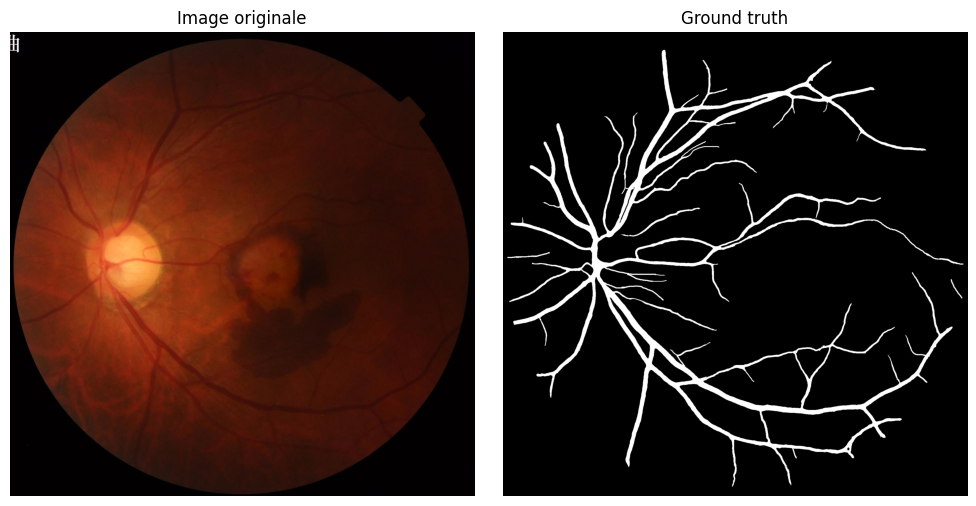

In [40]:
# Visualisation d'un exemple
num_obs = 0

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(load_img(train_img[num_obs]))
axes[0].set_title('Image originale')
axes[0].axis('off')

axes[1].imshow(load_label(train_label[num_obs]), cmap='gray')
axes[1].set_title('Ground truth')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Dataloaders

In [41]:
# Paramètres depuis la config
batch_size = config['training']['batch_size']
image_size = config['data']['image_size']
train_split = config['data']['train_split']

image_transform = transforms.Compose([
    transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
])

label_transform = transforms.Compose([
    transforms.Resize((image_size, image_size), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

dataset = VesselDataset(
    train_img,
    train_label,
    image_transform=image_transform,
    label_transform=label_transform,
 )

train_size = int(train_split * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Dataset créé avec image_size={image_size}, batch_size={batch_size}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Dataset créé avec image_size=256, batch_size=1
Train: 480, Val: 120


## Modèle

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Hyperparamètres depuis la config
EPOCHS = config['training']['n_epochs']
LR = config['training']['learning_rate']
PATIENCE = config['training']['patience']
epsilon = config['training']['epsilon']
dir_save = config['paths']['save_dir']

# Initialiser le modèle M2UNet avec poids pré-entraînés
model = get_model_from_config(config, device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Choix de la loss depuis la config
loss_name = config['training'].get('loss', 'BCEWithLogitsLoss')
if loss_name == 'DICE_BCE_Loss':
    criterion = DICE_BCE_Loss()
    print(f"Loss function: DICE_BCE_Loss")
elif loss_name == 'BCEWithLogitsLoss':
    criterion = nn.BCEWithLogitsLoss()
    print(f"Loss function: BCEWithLogitsLoss")
else:
    raise ValueError(f"Loss inconnue: {loss_name}. Choisir 'BCEWithLogitsLoss' ou 'DICE_BCE_Loss'")

# Variables pour la reprise d'entraînement
initial_train_losses = None
initial_val_losses = None

# Charger un checkpoint si reprise d'entraînement activée
if config['training'].get('resume_training', False):
    checkpoint_path = config['training'].get('resume_checkpoint_path')
    if checkpoint_path and os.path.isfile(checkpoint_path):
        try:
            model, optimizer, initial_train_losses, initial_val_losses = load_checkpoint(
                checkpoint_path, model, optimizer, device=device, loss_name=criterion
            )
            print(f"Checkpoint chargé avec succès !")
            print(f"  Historique chargé: {len(initial_train_losses)} epochs d'entraînement")
        except Exception as e:
            print(f"Erreur lors du chargement du checkpoint: {e}")
            print("  Démarrage du fine-tuning depuis les poids pré-entraînés...")
    else:
        print("Chemin du checkpoint non spécifié ou introuvable")
        print("  Démarrage du fine-tuning depuis les poids pré-entraînés...")
else:
    print("Démarrage du fine-tuning depuis les poids pré-entraînés M2UNet...")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Hyperparamètres:")
print(f"| Epochs: {EPOCHS}")
print(f"| Learning rate: {LR}")
print(f"| Patience: {PATIENCE}")
print(f"| Epsilon: {epsilon}")
print(f"| Epochs déjà entraînés: {len(initial_train_losses) if initial_train_losses else 0}")

Device: cuda
✓ Poids pré-entraînés M2UNet chargés depuis: ../saved_models/m2unet/M2UNetDRIVE.pth
Loss function: BCEWithLogitsLoss
Démarrage du fine-tuning depuis les poids pré-entraînés M2UNet...
Hyperparamètres:
| Epochs: 40
| Learning rate: 0.0001
| Patience: 50
| Epsilon: 0.5
| Epochs déjà entraînés: 0


## Training

In [8]:
# Déterminer le répertoire du modèle
model_dir = None
if initial_train_losses is not None and len(initial_train_losses) > 0:
    # Si c'est une reprise, récupérer le répertoire du checkpoint
    checkpoint_path = config['training'].get('resume_checkpoint_path')
    if checkpoint_path:
        model_dir = os.path.dirname(checkpoint_path)

train_losses, val_losses = train(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    device, 
    EPOCHS, 
    PATIENCE, 
    epsilon, 
    dir_save,
    initial_train_losses=initial_train_losses,
    initial_val_losses=initial_val_losses,
    model_dir=model_dir
)


100%|██████████| 120/120 [05:08<00:00,  2.57s/it]


Checkpoint sauvegardé à: ../saved_models/m2unet/train_20260313-142310/checkpoint.pth
Epoch 1/5 | Train: 0.8356 | Val: 0.8111


100%|██████████| 120/120 [04:37<00:00,  2.31s/it]


Checkpoint sauvegardé à: ../saved_models/m2unet/train_20260313-142310/checkpoint.pth
Epoch 2/5 | Train: 0.7749 | Val: 0.7788


100%|██████████| 120/120 [04:45<00:00,  2.38s/it]


Checkpoint sauvegardé à: ../saved_models/m2unet/train_20260313-142310/checkpoint.pth
Epoch 3/5 | Train: 0.7454 | Val: 0.7562


100%|██████████| 120/120 [04:37<00:00,  2.31s/it]


Checkpoint sauvegardé à: ../saved_models/m2unet/train_20260313-142310/checkpoint.pth
Epoch 4/5 | Train: 0.7206 | Val: 0.7343


100%|██████████| 120/120 [04:35<00:00,  2.30s/it]

Checkpoint sauvegardé à: ../saved_models/m2unet/train_20260313-142310/checkpoint.pth
Epoch 5/5 | Train: 0.6976 | Val: 0.7174


## Loss

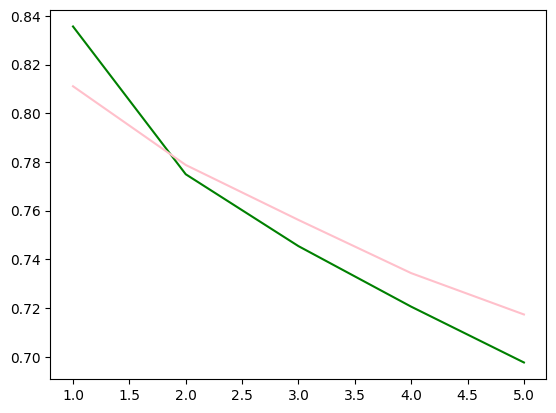

In [9]:
from src.utils.visualisation import viz_train_and_val_losses

viz_train_and_val_losses(train_losses, val_losses)